In [21]:
import cv2
import numpy as np


In [27]:
# Extract K and distortion coefficients from the camera calibration data
K = np.array([
    [673.84481, 0.0,       267.19239],
    [0.0,       689.86342, 238.83533],
    [0.0,       0.0,       1.0]
], dtype=np.float64)

dist_coeffs = np.array([-0.425541, 0.196418, -0.003610, 0.012352, 0.0], dtype=np.float64)

print("New K matrix:")
print(K)
print("\nNew distortion coefficients:")
print(dist_coeffs)


image = cv2.imread('/home/aki/Desktop/GitHub/Python-VO/Datasets/cusco_dataset_1/stereo_left/1780605914.688208.png')
h, w = image.shape[:2]
print("Image dimensions:", w, h)

New K matrix:
[[673.84481   0.      267.19239]
 [  0.      689.86342 238.83533]
 [  0.        0.        1.     ]]

New distortion coefficients:
[-0.425541  0.196418 -0.00361   0.012352  0.      ]
Image dimensions: 640 480


In [29]:
# 2. Refine the camera matrix using a free scaling parameter (alpha)
# alpha=0: Zoomed and cropped to remove all black edges. 
# alpha=1: Retains all pixels but keeps black margins where data is missing.
alpha = 0 
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (w, h), alpha, (w, h))

# 3. Undistort the image
dst = cv2.undistort(image, K, dist_coeffs, None, newcameramtx)

# 4. Optional: Crop the result based on the region of interest (ROI)
x, y, w, h = roi
dst_cropped = dst[y:y+h, x:x+w]

# 5. Save or show the result
cv2.imshow('Undistorted Image', dst_cropped)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Plotagem de CSVs

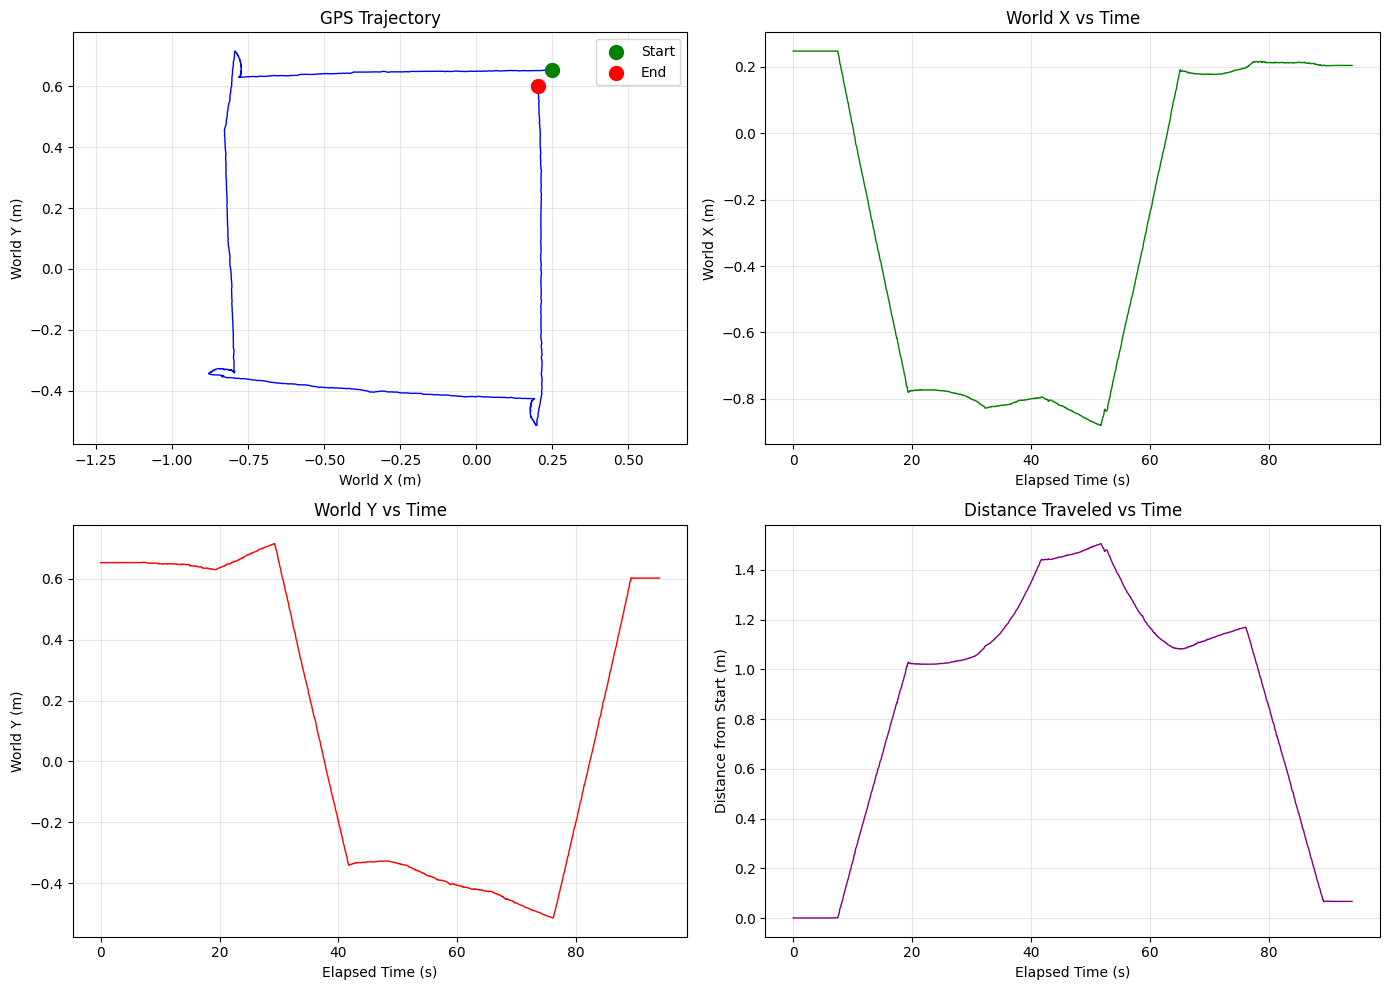

GPS Data shape: (1267, 6)

Data summary:
          timestamp      pixel_x      pixel_y    world_x_m    world_y_m  \
count  1.267000e+03  1267.000000  1267.000000  1267.000000  1267.000000   
mean   1.780606e+09   927.542226   588.560379    -0.292025     0.112887   
std    2.689166e+01   128.651901   172.320860     0.464176     0.480659   
min    1.780606e+09   764.000000   363.000000    -0.880262    -0.514831   
25%    1.780606e+09   788.000000   415.500000    -0.796115    -0.370388   
50%    1.780606e+09   933.000000   574.000000    -0.272303     0.072744   
75%    1.780606e+09  1065.000000   779.000000     0.204041     0.644907   
max    1.780606e+09  1077.000000   805.000000     0.247630     0.716173   

       elapsed_time  
count   1267.000000  
mean      47.226333  
std       26.891662  
min        0.000000  
25%       24.049814  
50%       47.185972  
75%       70.552678  
max       94.029006  


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the GPS CSV
gps_data = pd.read_csv('../Datasets/cusco_dataset_1/sensor_data/vrs_gps.csv')

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Trajectory plot (world coordinates)
axes[0, 0].plot(gps_data['world_x_m'], gps_data['world_y_m'], 'b-', linewidth=1)
axes[0, 0].scatter(gps_data['world_x_m'].iloc[0], gps_data['world_y_m'].iloc[0], 
                   color='green', s=100, label='Start', zorder=5)
axes[0, 0].scatter(gps_data['world_x_m'].iloc[-1], gps_data['world_y_m'].iloc[-1], 
                   color='red', s=100, label='End', zorder=5)
axes[0, 0].set_xlabel('World X (m)')
axes[0, 0].set_ylabel('World Y (m)')
axes[0, 0].set_title('GPS Trajectory')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axis('equal')

# 2. World X vs elapsed time
axes[0, 1].plot(gps_data['elapsed_time'], gps_data['world_x_m'], 'g-', linewidth=1)
axes[0, 1].set_xlabel('Elapsed Time (s)')
axes[0, 1].set_ylabel('World X (m)')
axes[0, 1].set_title('World X vs Time')
axes[0, 1].grid(True, alpha=0.3)

# 3. World Y vs elapsed time
axes[1, 0].plot(gps_data['elapsed_time'], gps_data['world_y_m'], 'r-', linewidth=1)
axes[1, 0].set_xlabel('Elapsed Time (s)')
axes[1, 0].set_ylabel('World Y (m)')
axes[1, 0].set_title('World Y vs Time')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distance from start point
start_x, start_y = gps_data['world_x_m'].iloc[0], gps_data['world_y_m'].iloc[0]
distance = np.sqrt((gps_data['world_x_m'] - start_x)**2 + 
                   (gps_data['world_y_m'] - start_y)**2)
axes[1, 1].plot(gps_data['elapsed_time'], distance, 'purple', linewidth=1)
axes[1, 1].set_xlabel('Elapsed Time (s)')
axes[1, 1].set_ylabel('Distance from Start (m)')
axes[1, 1].set_title('Distance Traveled vs Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GPS Data shape: {gps_data.shape}")
print(f"\nData summary:\n{gps_data.describe()}")

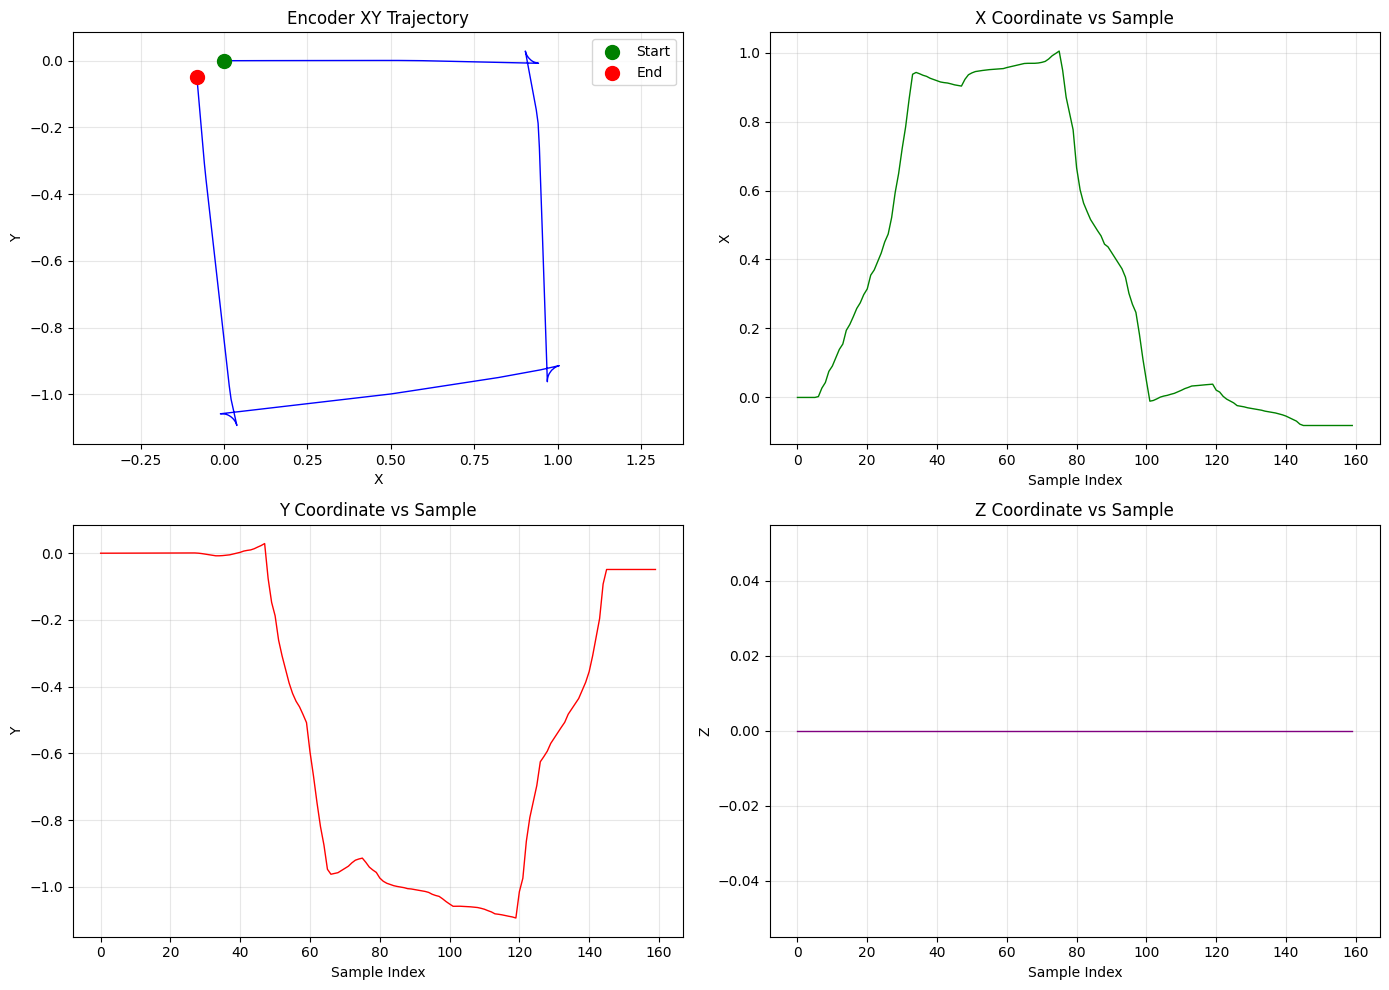

Encoder Data shape: (160, 5)

Data summary:
          timestamp           x           y      z
count  1.600000e+02  160.000000  160.000000  160.0
mean   1.780606e+09    0.373791   -0.484421    0.0
std    2.859832e+01    0.416922    0.447351    0.0
min    1.780606e+09   -0.081357   -1.093079    0.0
25%    1.780606e+09   -0.001032   -0.976247    0.0
50%    1.780606e+09    0.252328   -0.447079    0.0
75%    1.780606e+09    0.909914   -0.002682    0.0
max    1.780606e+09    1.004411    0.028919    0.0

First few rows:
      timestamp         image_filename    x    y    z
0  1.780606e+09  1780605588.594214.png  0.0  0.0  0.0
1  1.780606e+09  1780605588.761872.png  0.0  0.0  0.0
2  1.780606e+09  1780605589.025830.png  0.0  0.0  0.0
3  1.780606e+09  1780605589.362170.png  0.0  0.0  0.0
4  1.780606e+09  1780605589.594752.png  0.0  0.0  0.0

Last few rows:
        timestamp         image_filename         x        y    z
155  1.780606e+09  1780605675.223105.png -0.081357 -0.04876  0.0
156  1.780

In [31]:
# Load and plot encoder data
encoder_data = pd.read_csv('../Datasets/cusco_dataset_1/sensor_data/encoder.csv')

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. XY Trajectory (top-down view)
axes[0, 0].plot(encoder_data['x'], encoder_data['y'], 'b-', linewidth=1)
axes[0, 0].scatter(encoder_data['x'].iloc[0], encoder_data['y'].iloc[0], 
                   color='green', s=100, label='Start', zorder=5)
axes[0, 0].scatter(encoder_data['x'].iloc[-1], encoder_data['y'].iloc[-1], 
                   color='red', s=100, label='End', zorder=5)
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
axes[0, 0].set_title('Encoder XY Trajectory')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axis('equal')

# 2. X coordinate over time
axes[0, 1].plot(range(len(encoder_data)), encoder_data['x'], 'g-', linewidth=1)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('X')
axes[0, 1].set_title('X Coordinate vs Sample')
axes[0, 1].grid(True, alpha=0.3)

# 3. Y coordinate over time
axes[1, 0].plot(range(len(encoder_data)), encoder_data['y'], 'r-', linewidth=1)
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_title('Y Coordinate vs Sample')
axes[1, 0].grid(True, alpha=0.3)

# 4. Z coordinate (should be mostly 0)
axes[1, 1].plot(range(len(encoder_data)), encoder_data['z'], 'purple', linewidth=1)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Z')
axes[1, 1].set_title('Z Coordinate vs Sample')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Encoder Data shape: {encoder_data.shape}")
print(f"\nData summary:\n{encoder_data.describe()}")
print(f"\nFirst few rows:\n{encoder_data.head()}")
print(f"\nLast few rows:\n{encoder_data.tail()}")